# SVD and PCA for Dimensionality Reduction

By: Yashu Lanki

Course: AIT 525

Grand Canyon University

## Part 1: Dataset Selection

This dataset, sourced from Kaggle ("International Graduates Employment Dataset" by quackquackrp, n.d.), combines a record of anonymized international graduates and their outcomes after obtaining their degree. It is built from real survey data, including the UK HESA Graduate Outcomes Survey and the EU Labour Force Survey. The dataset contains 300,000 rows and 15 columns, with key features including Education_Level, Field_of_Study, Employment_Status, Salary, GPA, Age, and Years_Since_Graduation, along with additional details like Country_of_Origin, Visa_Type, and Language_Proficiency. The goal is to use predictive analysis to determine things like employment status, salary estimation, and feature analysis based on these graduates' academic and demographic backgrounds.

### Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


df = pd.read_csv("graduates_data/international_graduates_employment.csv")
print(df.shape)
df.head()

(300000, 15)


,Country_of_Origin,Education_Level,Field_of_Study,Language_Proficiency,Visa_Type,Gender,University_Ranking,Region_of_Study,Age,Years_Since_Graduation,GPA,Internship_Experience,Employment_Status,Salary,Job_Sector
0,Vietnam,Bachelor's,IT,Fluent,Permanent Residency,Female,Low,EU,23,8,3.76,Yes,Employed,54397,Healthcare
1,Germany,Master's,Arts,Intermediate,Post-study,Male,High,UK,38,9,3.76,No,Employed,69635,Finance
2,Brazil,PhD,Engineering,Intermediate,Post-study,Male,High,Canada,23,2,3.52,Yes,Employed,96216,Finance
3,Vietnam,PhD,Health,Fluent,Post-study,Female,Medium,Australia,25,5,3.28,Yes,Employed,86076,Other
4,Nigeria,PhD,Engineering,Basic,Student,Male,High,Canada,24,2,3.01,Yes,Employed,82772,Finance


In [2]:
numeric_columns = ['Age','Years_Since_Graduation','GPA','Salary']
X = df[numeric_columns]
print(X)

        Age  Years_Since_Graduation   GPA  Salary
0        23                       8  3.76   54397
1        38                       9  3.76   69635
2        23                       2  3.52   96216
3        25                       5  3.28   86076
4        24                       2  3.01   82772
...     ...                     ...   ...     ...
299995   29                       7  3.12       0
299996   22                       6  3.01   33632
299997   31                       3  3.48   87523
299998   37                       2  3.21       0
299999   34                       3  3.03   37734

[300000 rows x 4 columns]


In [3]:
df.columns

Index(['Country_of_Origin', 'Education_Level', 'Field_of_Study',
       'Language_Proficiency', 'Visa_Type', 'Gender', 'University_Ranking',
       'Region_of_Study', 'Age', 'Years_Since_Graduation', 'GPA',
       'Internship_Experience', 'Employment_Status', 'Salary', 'Job_Sector'],
      dtype='str')

## Data Preprocessing

Both SVD and PCA need one numeric feature matrix, so we build it once here: one-hot encode the categorical columns, combine them with the naturally numeric columns, then standardize everything (mean 0, standard deviation 1) using scikit-learn's `StandardScaler` so no single column dominates just because its raw numbers are bigger (Pedregosa et al., 2011).

In [4]:
categorical_columns = ['Country_of_Origin', 'Education_Level', 'Field_of_Study',
       'Language_Proficiency', 'Visa_Type', 'Gender', 'University_Ranking',
       'Region_of_Study','Internship_Experience','Job_Sector']

encoded = pd.get_dummies(df[categorical_columns], dtype=int)
X = pd.concat([X, encoded], axis=1)
print(X)

        Age  Years_Since_Graduation   GPA  Salary  Country_of_Origin_Brazil  \
0        23                       8  3.76   54397                         0   
1        38                       9  3.76   69635                         0   
2        23                       2  3.52   96216                         1   
3        25                       5  3.28   86076                         0   
4        24                       2  3.01   82772                         0   
...     ...                     ...   ...     ...                       ...   
299995   29                       7  3.12       0                         0   
299996   22                       6  3.01   33632                         0   
299997   31                       3  3.48   87523                         0   
299998   37                       2  3.21       0                         0   
299999   34                       3  3.03   37734                         0   

        Country_of_Origin_China  Country_of_Origin_

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.44487926  1.21613731  1.39809336 ... -0.26522243 -0.26510002
  -0.26342533]
 [ 1.44644057  1.5640176   1.39809336 ... -0.26522243 -0.26510002
  -0.26342533]
 [-1.44487926 -0.87114443  0.79851966 ... -0.26522243 -0.26510002
  -0.26342533]
 ...
 [ 0.09715798 -0.52326414  0.69859071 ... -0.26522243 -0.26510002
  -0.26342533]
 [ 1.25368592 -0.87114443  0.0240703  ... -0.26522243 -0.26510002
  -0.26342533]
 [ 0.67542195 -0.52326414 -0.42560997 ... -0.26522243 -0.26510002
  -0.26342533]]


## Part 2: Using SVD to Reduce Data Dimensionality

Singular Value Decomposition factors any matrix A into three components, A = UΣVᵀ, where U and V are orthogonal matrices and Σ is a diagonal matrix of singular values ranked from largest to smallest, each one measuring how much of the data's variance that component captures (GeeksforGeeks, 2025; Nelson, 2023). We compute this with NumPy's `linalg.svd` function (NumPy Developers, n.d.).

In [6]:
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
print(U.shape)
print(S.shape)
print(Vt.shape)


(300000, 50)
(50,)
(50, 50)


In [7]:
explained_variance_ratio = S**2 / np.sum(S**2)
cumulative_explained = np.cumsum(explained_variance_ratio)
print(explained_variance_ratio.shape)
print(cumulative_explained.shape)

(50,)
(50,)


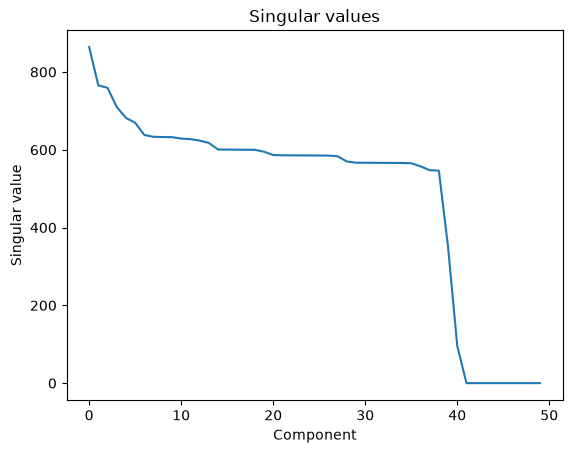

In [8]:
plt.plot(S)
plt.xlabel('Component')
plt.ylabel('Singular value')
plt.title('Singular values')
plt.show()

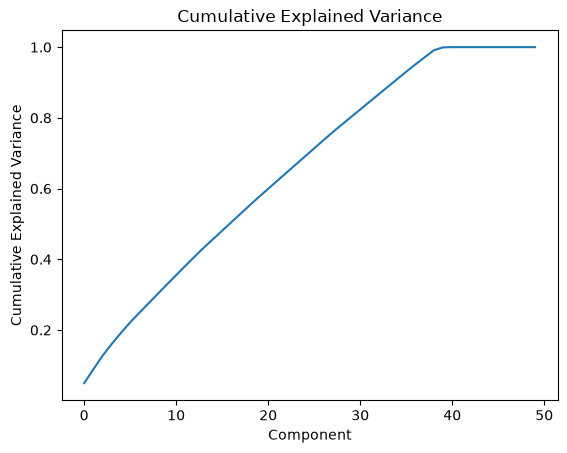

In [9]:
plt.plot(cumulative_explained)
plt.xlabel('Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.show()

In [10]:
k = 5
Z = U[:, :k] @ np.diag(S[:k])
print(Z.shape)

(300000, 5)


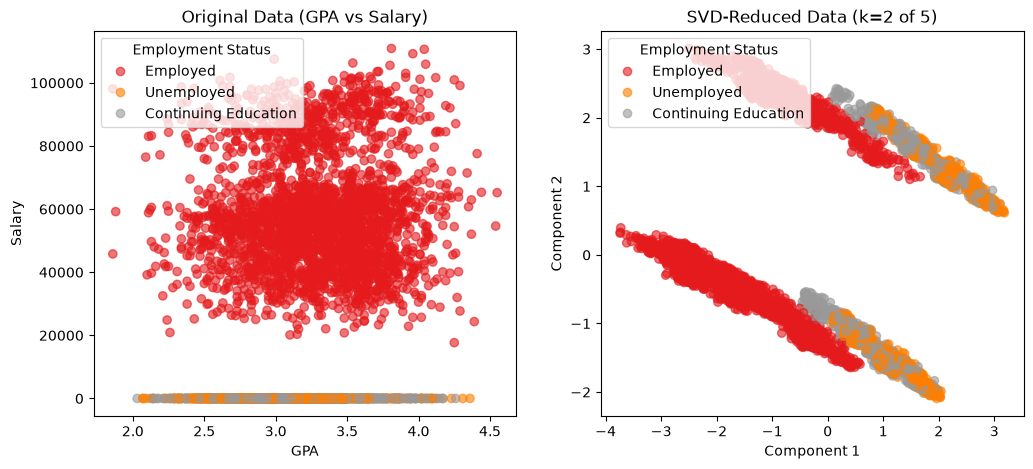

In [11]:
codes, categories = pd.factorize(df['Employment_Status'])

sample_idx = df.sample(5000, random_state=42).index
sample_labels = codes[sample_idx]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(df.loc[sample_idx, 'GPA'], df.loc[sample_idx, 'Salary'], c=sample_labels, cmap='Set1', alpha=0.6)
plt.xlabel('GPA')
plt.ylabel('Salary')
plt.title('Original Data (GPA vs Salary)')
plt.legend(scatter1.legend_elements()[0], categories, title='Employment Status')

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(Z[sample_idx, 0], Z[sample_idx, 1], c=sample_labels, cmap='Set1', alpha=0.6)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('SVD-Reduced Data (k=2 of 5)')
plt.legend(scatter2.legend_elements()[0], categories, title='Employment Status', loc='upper left')

plt.show()

**Trade-offs.** Reducing from 50 features down to k=5 means we lose the ability to see individual features clearly — a component is a blend of dozens of original columns, so it's no longer possible to say "this axis is GPA" or "this axis is Field_of_Study." That's a real cost, and it's a steep one here: k=5 only captures about 19% of the total variance, while the actual "elbow" in the singular values doesn't appear until around component 40 — meaning most of the dataset's real structure lives well beyond the top 5 components. What we gain in exchange is visibility: the SVD-reduced scatterplot showed more visible separation between Employment_Status groups than the raw GPA-vs-Salary plot did, since those 2 components draw on signal from all 50 features rather than just 2. In practice, k=5 is reasonable for a quick 2D visualization or exploratory look, but too aggressive a cut if the goal were to actually predict employment status — a model built on 5 components would be throwing away roughly 80% of the dataset's variance.

## Part 3: Using PCA to Reduce Data Dimensionality

Principal Component Analysis finds new axes, called principal components, that point in the directions of maximum variance in the data, ordered from most to least important (GeeksforGeeks, 2026; Nelson, 2023). We use scikit-learn's `PCA` class to compute this directly (Pedregosa et al., 2011).

In [12]:
pca = PCA()
pca.fit(X_scaled)

print(pca.explained_variance_ratio_.shape)

cumulative_pca = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_pca.shape)

(50,)
(50,)


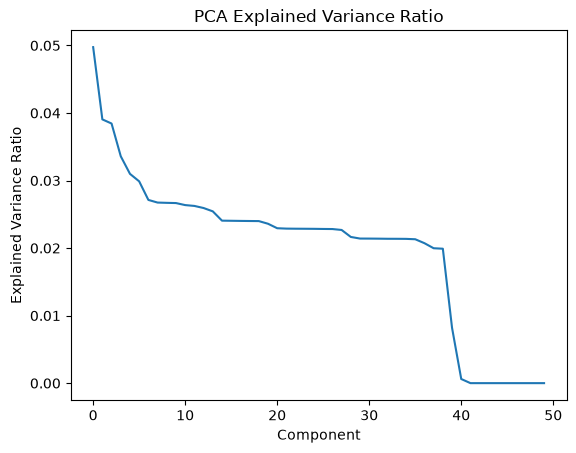

In [13]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance Ratio')
plt.show()

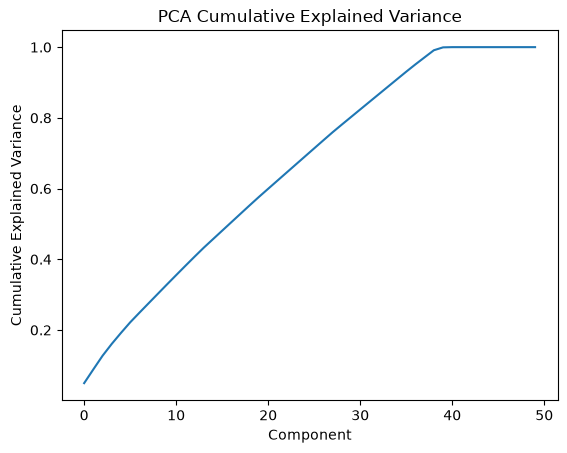

In [14]:
plt.plot(cumulative_pca)
plt.xlabel('Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.show()

In [15]:
pca_k = PCA(n_components=5)
Z_pca = pca_k.fit_transform(X_scaled)
print(Z_pca.shape)

(300000, 5)


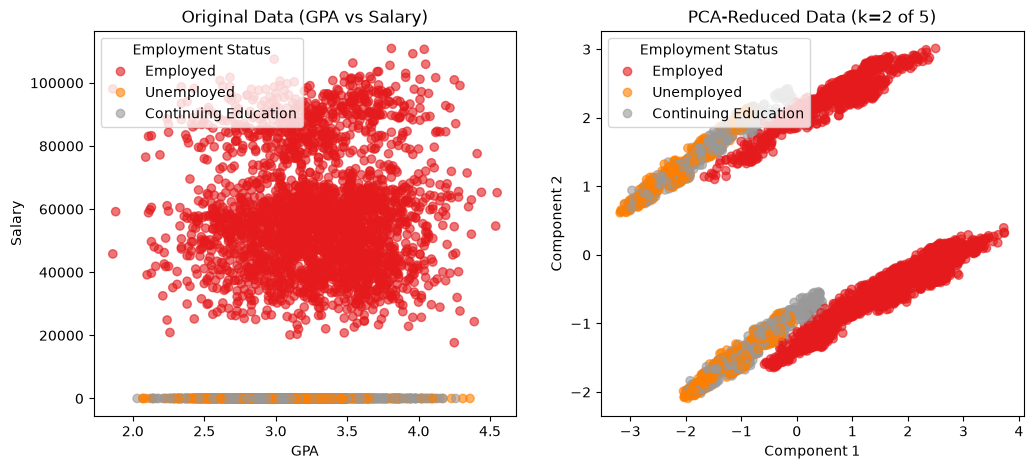

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter3 = plt.scatter(df.loc[sample_idx, 'GPA'], df.loc[sample_idx, 'Salary'], c=sample_labels, cmap='Set1', alpha=0.6)
plt.xlabel('GPA')
plt.ylabel('Salary')
plt.title('Original Data (GPA vs Salary)')
plt.legend(scatter3.legend_elements()[0], categories, title='Employment Status')

plt.subplot(1, 2, 2)
scatter4 = plt.scatter(Z_pca[sample_idx, 0], Z_pca[sample_idx, 1], c=sample_labels, cmap='Set1', alpha=0.6)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('PCA-Reduced Data (k=2 of 5)')
plt.legend(scatter4.legend_elements()[0], categories, title='Employment Status', loc='upper left')

plt.show()

**Trade-offs.** The PCA trade-offs are essentially identical to SVD's, and that's not a coincidence — PCA and SVD are doing nearly the same underlying math on standardized data (PCA is just SVD applied to centered/scaled data). At k=5, PCA captures 19.18% of the total variance, matching SVD's 19.18% almost exactly. So the same costs apply: we lose the ability to see individual features clearly, since each component blends dozens of original columns, and k=5 is a steep cut relative to the ~40 components where the real elbow sits. The same benefit also holds: the PCA-reduced scatterplot showed more visible separation between Employment_Status groups than the raw 2-feature view did. The practical takeaway is the same too — k=5 works fine for a quick visualization, but is too aggressive for actually modeling employment outcomes.

## Part 4: Comparing SVD and PCA

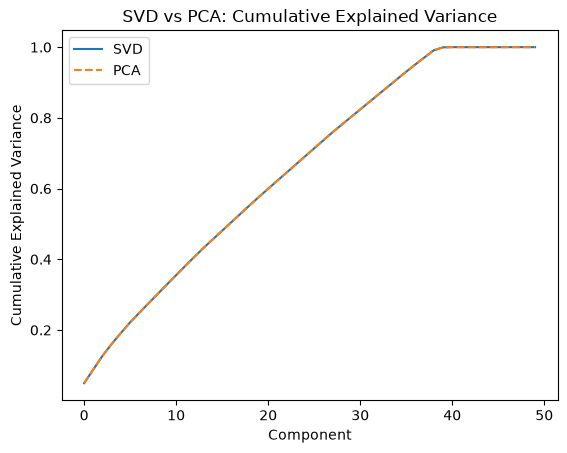

In [17]:
plt.plot(cumulative_explained, label = 'SVD')
plt.plot(cumulative_pca, label = 'PCA', linestyle = '--')
plt.xlabel('Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('SVD vs PCA: Cumulative Explained Variance')
plt.legend()
plt.show()

In [18]:
component_0_svd = Vt[0]
component_0_pca = pca.components_[0]

print(component_0_svd[:5])
print(component_0_pca[:5])

print(np.allclose(np.abs(component_0_svd), np.abs(component_0_pca)))

[ 2.29921983e-03  7.54266015e-02 -1.06692848e-01 -5.65334273e-01
  4.62237897e-04]
[-2.29921983e-03 -7.54266015e-02  1.06692848e-01  5.65334273e-01
 -4.62237897e-04]
True


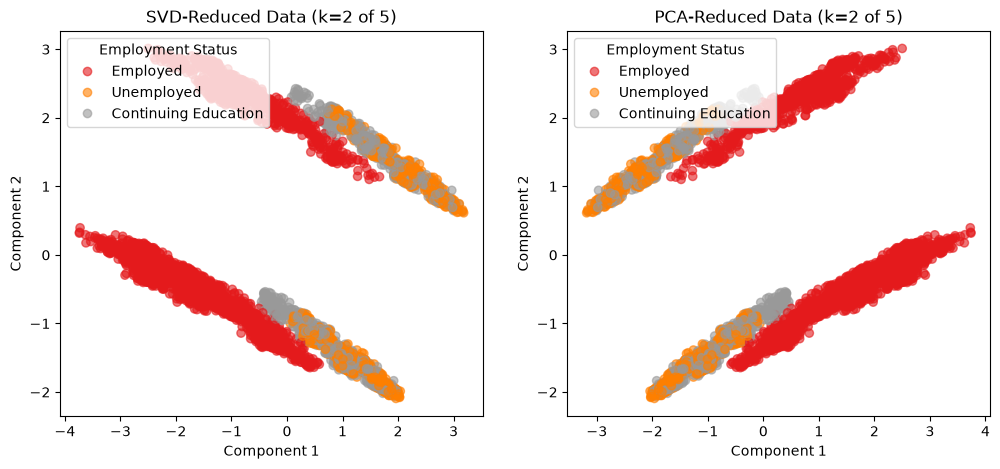

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter5 = plt.scatter(Z[sample_idx, 0], Z[sample_idx, 1], c=sample_labels, cmap='Set1', alpha=0.6)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('SVD-Reduced Data (k=2 of 5)')
plt.legend(scatter5.legend_elements()[0], categories, title='Employment Status', loc='upper left')

plt.subplot(1, 2, 2)
scatter6 = plt.scatter(Z_pca[sample_idx, 0], Z_pca[sample_idx, 1], c=sample_labels, cmap='Set1', alpha=0.6)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.title('PCA-Reduced Data (k=2 of 5)')
plt.legend(scatter6.legend_elements()[0], categories, title='Employment Status', loc='upper left')

plt.show()

**Strengths, limitations, and when to use each.** On this dataset, SVD and PCA produced essentially identical results — same explained variance, same loadings (up to a sign flip), same visual separation between Employment_Status groups. That agreement is itself useful: it acts as a built-in cross-check, making the conclusion that these 5 components genuinely capture the data's dominant structure more concrete than if we'd only tried one method. That said, the two techniques aren't interchangeable in general. PCA required less manual work here — scikit-learn's `PCA` class hands you `explained_variance_ratio_` directly, whereas with SVD we had to compute explained variance ourselves from the singular values. On the other hand, SVD is more general: it works on any matrix, including ones that aren't centered or standardized, which is why it shows up in contexts PCA doesn't, like recommender systems, image compression, and text/topic modeling (latent semantic analysis). For a standard machine-learning preprocessing task like this one, where the data is already being standardized anyway, PCA is the more practical choice simply because it's more convenient. SVD becomes preferable when working with raw, non-centered, or non-square data, or when the underlying factorization itself (not just a dimensionality-reduced feature set) is what's needed.

## References

GeeksforGeeks. (2025, July 5). *Singular value decomposition (SVD)*. https://www.geeksforgeeks.org/data-science/singular-value-decomposition-svd/

GeeksforGeeks. (2026, July 10). *Principal component analysis (PCA)*. https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

Nelson, H. (2023). *Essential math for AI: Next-level mathematics for efficient and successful AI systems*. O'Reilly Media.

NumPy Developers. (n.d.). *numpy.linalg.svd*. NumPy. Retrieved September 22, 2026, from https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

quackquackrp. (n.d.). *International graduates employment dataset* [Data set]. Kaggle. Retrieved September 18, 2026, from https://www.kaggle.com/datasets/quackquackrp/international-graduates-employment-dataset